# 05.02 — Leakage-Safe Temporal Splits

## Purpose

Inspect event volume and prevalence over time, then define explicit non-overlapping
calendar partitions. Random splitting is deliberately not used.

## Setup

In [ ]:
from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CURRENT_PATH = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT_PATH, *CURRENT_PATH.parents)
     if (path / "README.md").is_file() and (path / ".git").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the movie_rating_predictor repository root")

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "rating_features_v1.parquet"
FEATURE_METADATA_PATH = PROJECT_ROOT / "data" / "features" / "rating_features_v1.metadata.json"
RATINGS_PATH = PROJECT_ROOT / "data" / "processed" / "ratings.parquet"
MODELS_DIR = PROJECT_ROOT / "models"

FEATURE_COLUMNS = [
    "global_rating_count",
    "global_mean_rating",
    "user_rating_count",
    "user_mean_rating",
    "user_rating_std_pop",
    "user_seconds_since_last_rating",
    "movie_rating_count",
    "movie_mean_rating",
    "movie_rating_std_pop",
    "movie_rating_count_30d",
    "user_target_genre_rating_count",
    "user_target_genre_mean_rating",
    "user_target_genre_mean_delta",
    "movie_genre_count",
    "movie_release_year",
    "movie_release_year_missing",
    "movie_age_years",
]

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Random seed:", RANDOM_SEED)
print("Feature count:", len(FEATURE_COLUMNS))
print("Features:", FEATURE_COLUMNS)


TRAIN_END = pd.Timestamp("2012-01-01")
VALIDATION_END = pd.Timestamp("2014-01-01")

SPLIT_DEFINITIONS = {
    "train": {"start": None, "end": TRAIN_END},
    "validation": {"start": TRAIN_END, "end": VALIDATION_END},
    "test": {"start": VALIDATION_END, "end": None},
}

def split_mask(timestamp: pd.Series, split_name: str) -> np.ndarray:
    bounds = SPLIT_DEFINITIONS[split_name]
    mask = np.ones(len(timestamp), dtype=bool)
    if bounds["start"] is not None:
        mask &= timestamp.to_numpy() >= bounds["start"].to_datetime64()
    if bounds["end"] is not None:
        mask &= timestamp.to_numpy() < bounds["end"].to_datetime64()
    return mask

Python: 3.14.6
pandas: 3.0.5
NumPy: 2.5.3
Random seed: 42
Feature count: 17
Features: ['global_rating_count', 'global_mean_rating', 'user_rating_count', 'user_mean_rating', 'user_rating_std_pop', 'user_seconds_since_last_rating', 'movie_rating_count', 'movie_mean_rating', 'movie_rating_std_pop', 'movie_rating_count_30d', 'user_target_genre_rating_count', 'user_target_genre_mean_rating', 'user_target_genre_mean_delta', 'movie_genre_count', 'movie_release_year', 'movie_release_year_missing', 'movie_age_years']


## Load event time and outcome only

This notebook does not load the 17-column feature matrix because distribution and
split checks require only canonical event identity, time, and outcome.

In [ ]:
events = pd.read_parquet(FEATURE_PATH, columns=["ratingEventId", "timestamp"])
ratings = pd.read_parquet(RATINGS_PATH, columns=["rating"])
rating_values = ratings["rating"].to_numpy(dtype=np.float32, copy=False)
event_ids = events["ratingEventId"].to_numpy(dtype=np.uint64, copy=False)
y = (rating_values[event_ids - 1] >= 4.0).astype(np.int8)
assert len(events) == len(ratings)
print("Rows:", f"{len(events):,}")

Rows: 20,000,263


## Distribution over time

Calendar counts expose natural boundary choices and potential target drift.

In [ ]:
temporal = pd.DataFrame({"timestamp": events["timestamp"], "highRating": y})
temporal["year"] = temporal["timestamp"].dt.year
temporal["quarter"] = temporal["timestamp"].dt.to_period("Q")

yearly = temporal.groupby("year", observed=True)["highRating"].agg(rows="size", positives="sum", prevalence="mean")
quarterly = temporal.groupby("quarter", observed=True)["highRating"].agg(rows="size", positives="sum", prevalence="mean")
display(yearly)
display(quarterly.tail(20))

,rows,positives,prevalence
year,,,
1995,4,2,0.500000
1996,1612609,787998,0.488648
1997,700982,362555,0.517210
1998,308070,167621,0.544100
1999,1198384,707182,0.590113
2000,1953659,1121304,0.573951
2001,1186125,659094,0.555670
2002,869719,466210,0.536047
2003,1035878,498628,0.481358


,rows,positives,prevalence
quarter,,,
2010Q2,195134,92850,0.475827
2010Q3,254666,124577,0.489178
2010Q4,233615,113421,0.485504
2011Q1,225851,109722,0.485816
2011Q2,209702,104457,0.498121
2011Q3,172080,83063,0.482700
2011Q4,158733,77747,0.489797
2012Q1,178674,88484,0.495226
2012Q2,206849,106889,0.516749


Matplotlib is building the font cache; this may take a moment.


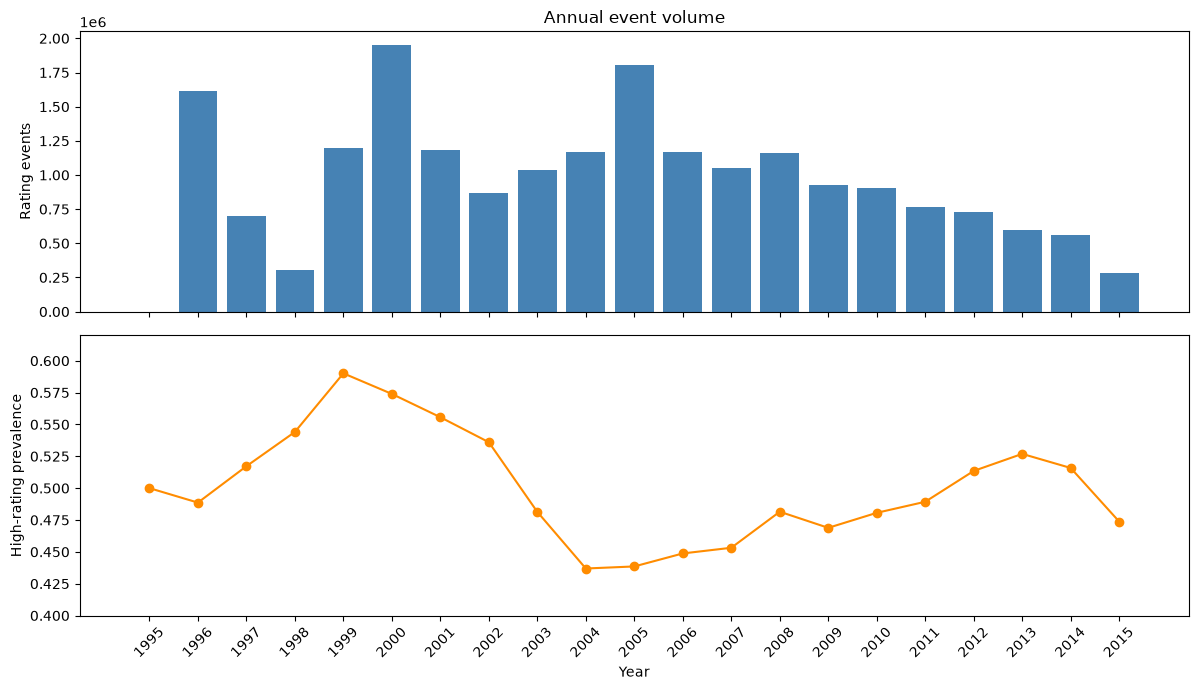

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(yearly.index.astype(str), yearly["rows"], color="steelblue")
axes[0].set_ylabel("Rating events")
axes[0].set_title("Annual event volume")
axes[1].plot(yearly.index.astype(str), yearly["prevalence"], marker="o", color="darkorange")
axes[1].set_ylabel("High-rating prevalence")
axes[1].set_xlabel("Year")
axes[1].set_ylim(0.4, 0.62)
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Chosen boundaries

Use half-open calendar intervals so no timestamp can appear in two splits:

- train: timestamps before 2012-01-01
- validation: 2012-01-01 through 2013-12-31
- test: 2014-01-01 onward

These boundaries preserve 17.8M training examples while leaving 1.33M validation
and 0.85M untouched test examples across multiple quarters.

In [ ]:
split_rows = []
split_masks = {}
for name in SPLIT_DEFINITIONS:
    mask = split_mask(events["timestamp"], name)
    split_masks[name] = mask
    timestamps = events.loc[mask, "timestamp"]
    split_rows.append({
        "Split": name,
        "Configured start (inclusive)": SPLIT_DEFINITIONS[name]["start"],
        "Configured end (exclusive)": SPLIT_DEFINITIONS[name]["end"],
        "Actual min timestamp": timestamps.min(),
        "Actual max timestamp": timestamps.max(),
        "Rows": int(mask.sum()),
        "Prevalence": float(y[mask].mean()),
    })

split_summary = pd.DataFrame(split_rows).set_index("Split")
display(split_summary)
assert sum(mask.sum() for mask in split_masks.values()) == len(events)
assert not np.any(split_masks["train"] & split_masks["validation"])
assert not np.any(split_masks["train"] & split_masks["test"])
assert not np.any(split_masks["validation"] & split_masks["test"])
assert events.loc[split_masks["train"], "timestamp"].max() < events.loc[split_masks["validation"], "timestamp"].min()
assert events.loc[split_masks["validation"], "timestamp"].max() < events.loc[split_masks["test"], "timestamp"].min()
print("Temporal ordering and disjointness: PASS")

,Configured start (inclusive),Configured end (exclusive),Actual min timestamp,Actual max timestamp,Rows,Prevalence
Split,,,,,,
train,NaT,2012-01-01,1995-01-09 11:46:44,2011-12-31 23:59:55,17822773,0.498194
validation,2012-01-01,2014-01-01,2012-01-01 00:00:40,2013-12-31 23:59:59,1330716,0.519539
test,2014-01-01,NaT,2014-01-01 00:00:04,2015-03-31 06:40:02,846774,0.501728


Temporal ordering and disjointness: PASS


## Persist lightweight split metadata

Only boundaries and summaries are saved. The feature dataset is not duplicated.

In [ ]:
MODELS_DIR.mkdir(exist_ok=True)
split_metadata = {
    "random_seed": RANDOM_SEED,
    "boundary_convention": "start inclusive, end exclusive",
    "feature_contract_version": json.loads(FEATURE_METADATA_PATH.read_text())["featureContractVersion"],
    "splits": {},
}
for name, row in split_summary.iterrows():
    bounds = SPLIT_DEFINITIONS[name]
    split_metadata["splits"][name] = {
        "start_inclusive": None if bounds["start"] is None else bounds["start"].isoformat(),
        "end_exclusive": None if bounds["end"] is None else bounds["end"].isoformat(),
        "actual_min_timestamp": row["Actual min timestamp"].isoformat(),
        "actual_max_timestamp": row["Actual max timestamp"].isoformat(),
        "rows": int(row["Rows"]),
        "prevalence": float(row["Prevalence"]),
    }

split_path = MODELS_DIR / "phase5_temporal_splits.json"
split_path.write_text(json.dumps(split_metadata, indent=2) + "\n")
print("Saved:", split_path.relative_to(PROJECT_ROOT))

Saved: models/phase5_temporal_splits.json
